# Lab 07 — Full Supervised Fine-Tuning

**Goal:** fully fine-tune all ~596M parameters of `Qwen/Qwen3-0.6B` on the synthetic Wordle curriculum from Lab 06, then measure whether the model's actual Wordle behavior improves.

This is the first real end-to-end training experiment.

Our baseline from Lab 04 was:

```text
solve rate:                 5.0%
feedback-dependent solves:  0
valid output rate:        100.0%
history consistency:        0.0%
repeat guesses:            76
```

The primary question is not "does training loss go down?"

It is:

> Does supervised fine-tuning make Qwen use Wordle feedback correctly?

We start with **full fine-tuning** rather than LoRA because the goal is to learn the mechanics of model training. Your M3 Ultra has enough memory that we do not need to introduce parameter-efficiency techniques yet.

## 7.1 Restart the kernel

Lab 07 should begin from a clean Jupyter kernel.

Why?

Previous labs may have:

- loaded other model instances;
- modified weights during Lab 02;
- retained large tensors in MPS memory.

Restart the kernel, then run this notebook from the top.

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"
MAX_LENGTH = 128
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 7.2 Load the persisted Lab 06 dataset

Training begins from saved artifacts, not notebook variables.

That boundary matters. It means the exact dataset can be regenerated, inspected, versioned, and reused independently of training code.

In [3]:
DATA_DIR = Path("../data/generated")

data_files = {
    "train": str(DATA_DIR / "wordle-sft-train.jsonl"),
    "validation": str(DATA_DIR / "wordle-sft-dev.jsonl"),
    "test": str(DATA_DIR / "wordle-sft-test.jsonl"),
}

dataset = load_dataset(
    "json",
    data_files=data_files,
)

print(dataset)

manifest_path = DATA_DIR / "wordle-sft-manifest.json"
manifest = json.loads(manifest_path.read_text())

print("\nmanifest version:", manifest["version"])
print("training rows:", dataset["train"].num_rows)
print("validation rows:", dataset["validation"].num_rows)
print("test rows:", dataset["test"].num_rows)

DatasetDict({
    train: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 16465
    })
    validation: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 2169
    })
    test: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 190
    })
})

manifest version: 2
training rows: 16465
validation rows: 2169
test rows: 190


Expected sizes from Lab 06 v2:

```text
train       16,465
validation   2,169
test           190
```

If these differ, stop. Do not silently train on a different dataset than the one we validated.

In [4]:
assert dataset["train"].num_rows == 16465
assert dataset["validation"].num_rows == 2169
assert dataset["test"].num_rows == 190

print("Dataset sizes match Lab 06.")

Dataset sizes match Lab 06.


## 7.3 Load untouched Qwen3-0.6B

We use float32 again.

That is not necessarily the fastest possible choice on Apple Silicon. It is the simplest experimental choice and removes precision as a variable from this first run.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
).to(device)

print(type(model).__name__)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("trainable:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("dtype:", next(model.parameters()).dtype)
print("device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen3ForCausalLM
parameters: 596,049,920
trainable: 596,049,920
dtype: torch.float32
device: mps:0


Every parameter is trainable:

```text
~596M total
~596M trainable
```

Later, Lab 08 will make this comparison concrete by freezing the base weights and training only LoRA adapters.

## 7.4 Format one training example

As in Lab 02, the model sees a chat conversation:

```text
user prompt
assistant response
```

But the loss should apply only to the assistant response tokens.

We use Qwen's chat template with thinking disabled.

In [6]:
def render_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def render_full_example(prompt: str, response: str) -> tuple[str, str]:
    prompt_text = render_prompt(prompt)
    full_text = prompt_text + response + tokenizer.eos_token
    return prompt_text, full_text

row = dataset["train"][0]
prompt_text, full_text = render_full_example(
    row["prompt"],
    row["response"],
)

print("PROMPT TEMPLATE")
print(prompt_text)
print("\nFULL TRAINING TEXT")
print(full_text)

PROMPT TEMPLATE
<|im_start|>user
Task: VALID_CANDIDATE
You are playing Wordle.
Given the game history, decide whether the candidate could still be the hidden answer.
Return exactly VALID or INVALID.

History:
R A I S E -> B Y B B B

Candidate: A L O N G<|im_end|>
<|im_start|>assistant
<think>

</think>



FULL TRAINING TEXT
<|im_start|>user
Task: VALID_CANDIDATE
You are playing Wordle.
Given the game history, decide whether the candidate could still be the hidden answer.
Return exactly VALID or INVALID.

History:
R A I S E -> B Y B B B

Candidate: A L O N G<|im_end|>
<|im_start|>assistant
<think>

</think>

VALID<|im_end|>


## 7.5 Encode with response-only labels

The key idea from Lab 02 returns:

```text
prompt tokens   → label -100
response tokens → actual token IDs
padding         → label -100
```

`-100` tells PyTorch's causal-LM loss to ignore that position.

So Qwen can read the whole prompt, but we only train it on the assistant answer.

In [8]:
def encode_example(example: dict) -> dict:
    prompt_text, full_text = render_full_example(
        example["prompt"],
        example["response"],
    )

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    full_ids = tokenizer(
        full_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    if len(full_ids) >= MAX_LENGTH:
        raise ValueError(
            "Example reached MAX_LENGTH. "
            "Re-check truncation before training."
        )

    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]

    assert len(labels) == len(full_ids)
    assert any(label != -100 for label in labels)

    return {
        "input_ids": full_ids,
        "labels": labels,
        "task": example["task"],
    }

encoded_example = encode_example(dataset["train"][0])

print("input tokens:", len(encoded_example["input_ids"]))
print("supervised tokens:", sum(x != -100 for x in encoded_example["labels"]))
print("task:", encoded_example["task"])

input tokens: 71
supervised tokens: 2
task: VALID_CANDIDATE


## 7.6 Check every sequence before training

We already measured a maximum of 126 tokens in Lab 06. Verify that the exact Lab 07 formatting path still fits under 128.

This catches a surprisingly common error: changing formatting after measuring lengths.

In [9]:
def sequence_length(example: dict) -> int:
    _, full_text = render_full_example(
        example["prompt"],
        example["response"],
    )
    return len(
        tokenizer.encode(
            full_text,
            add_special_tokens=False,
        )
    )

max_train_length = max(
    sequence_length(x)
    for x in dataset["train"]
)

max_val_length = max(
    sequence_length(x)
    for x in dataset["validation"]
)

print("max train length:", max_train_length)
print("max validation length:", max_val_length)

assert max_train_length < MAX_LENGTH
assert max_val_length < MAX_LENGTH

max train length: 125
max validation length: 125


## 7.7 Build the collator

Each batch must be rectangular, so shorter examples are padded.

Padding contributes neither attention nor loss.

In [10]:
PAD_ID = tokenizer.pad_token_id
if PAD_ID is None:
    PAD_ID = tokenizer.eos_token_id

def collate_batch(rows: list[dict]) -> dict[str, torch.Tensor]:
    encoded = [encode_example(row) for row in rows]
    max_len = max(len(x["input_ids"]) for x in encoded)

    input_rows = []
    label_rows = []
    attention_rows = []

    for item in encoded:
        ids = item["input_ids"]
        labels = item["labels"]

        pad = max_len - len(ids)

        input_rows.append(ids + [PAD_ID] * pad)
        label_rows.append(labels + [-100] * pad)
        attention_rows.append([1] * len(ids) + [0] * pad)

    return {
        "input_ids": torch.tensor(input_rows, dtype=torch.long),
        "labels": torch.tensor(label_rows, dtype=torch.long),
        "attention_mask": torch.tensor(attention_rows, dtype=torch.long),
    }

## 7.8 Choose an initial batch size empirically

Your machine has enormous memory capacity, but MPS throughput is still sensitive to batch shape.

Start with:

```text
micro-batch = 16
```

We are not trying to maximize utilization yet. We are trying to get one trustworthy training run.

If this is comfortably fast, later experiments can increase it.

In [11]:
BATCH_SIZE = 16
VAL_BATCH_SIZE = 32

train_loader = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(
    dataset["validation"],
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))

train batches: 1030
validation batches: 68


With 16,465 training rows and batch size 16, one epoch should be roughly 1,030 optimizer steps.

That is large enough to learn something, but small enough that we can inspect the entire run.

## 7.9 Measure the untouched model on curriculum tasks

Before changing weights, evaluate validation loss.

This is not the Wordle-game benchmark yet. It measures how well Qwen predicts the synthetic task targets.

In [12]:
@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    max_batches: int | None = None,
) -> float:
    model.eval()
    losses = []

    for batch_i, batch in enumerate(loader):
        if max_batches is not None and batch_i >= max_batches:
            break

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(**batch)
        losses.append(outputs.loss.detach().float().cpu().item())

    model.train()
    return float(np.mean(losses))

model.train()

baseline_val_loss = evaluate_loss(
    model,
    val_loader,
    max_batches=None,
)

print("baseline validation loss:", baseline_val_loss)
print("baseline validation perplexity:", math.exp(baseline_val_loss))

baseline validation loss: 8.550293193143958
baseline validation perplexity: 5168.269506245097


Perplexity is included because you'll encounter it frequently, but validation loss is the more useful metric for this experiment.

Neither substitutes for the real Wordle benchmark.

## 7.10 Inspect generations before training

Take one example from each task and ask the untouched model to answer it.

We want a behavioral before-state alongside validation loss.

In [13]:
def generate_response(prompt: str, max_new_tokens: int = 16) -> str:
    text = render_prompt(prompt)
    batch = tokenizer(text, return_tensors="pt").to(device)

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    new = output[0, batch["input_ids"].shape[1]:]
    result = tokenizer.decode(
        new,
        skip_special_tokens=True,
    ).strip()

    model.train()
    return result

for task in ["VALID_CANDIDATE", "CHOOSE_VALID", "NEXT_GUESS"]:
    row = next(
        x for x in dataset["validation"]
        if x["task"] == task
    )

    print("=" * 80)
    print("TASK:", task)
    print("TARGET:", row["response"])
    print("MODEL:", generate_response(row["prompt"]))

TASK: VALID_CANDIDATE
TARGET: VALID
MODEL: To determine whether the candidate "L E A F Y" could still be the
TASK: CHOOSE_VALID
TARGET: ATTIC
MODEL: The valid five-letter word consistent with all previous feedback is: **E R E
TASK: NEXT_GUESS
TARGET: ADORN
MODEL: Y E B B B


## 7.11 Optimizer and learning rate

We start conservatively:

```text
AdamW
learning rate = 2e-5
weight decay = 0.01
```

Why not immediately use a larger learning rate?

Because we're updating all 596M pretrained parameters. Full fine-tuning can destroy useful pretrained behavior if the updates are too aggressive.

We will measure first.

In [14]:
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

## 7.12 Warmup + cosine learning-rate schedule

A fixed learning rate works, but this is a good point to introduce scheduling.

We use:

- 5% linear warmup;
- cosine decay for the rest of the epoch.

Warmup avoids immediately applying the full learning rate while the optimizer state is empty.

In [15]:
EPOCHS = 1

total_steps = len(train_loader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.05))

def lr_multiplier(step: int) -> float:
    if step < warmup_steps:
        return (step + 1) / warmup_steps

    progress = (
        (step - warmup_steps)
        / max(1, total_steps - warmup_steps)
    )

    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_multiplier,
)

print("total steps:", total_steps)
print("warmup steps:", warmup_steps)

total steps: 1030
warmup steps: 51


## 7.13 One batch sanity check

Before launching 1,000+ steps:

1. forward pass;
2. backward pass;
3. inspect gradient norm;
4. **do not** call optimizer step yet.

If this fails, debugging a full epoch would be pointless.

In [16]:
batch = next(iter(train_loader))
batch = {
    key: value.to(device)
    for key, value in batch.items()
}

model.train()
optimizer.zero_grad(set_to_none=True)

outputs = model(**batch)
loss = outputs.loss
loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0,
)

print("sanity loss:", loss.detach().float().cpu().item())
print("gradient norm before clipping:", float(grad_norm))

sanity loss: 9.484407424926758
gradient norm before clipping: 1893.400146484375


Clear those gradients before the real run:

In [17]:
optimizer.zero_grad(set_to_none=True)

## 7.14 Training loop

This is the same loop as Lab 02, just repeated over real batches:

```text
forward
loss
backward
clip gradients
optimizer step
scheduler step
zero gradients
```

We evaluate the full validation set every 200 steps and at the end.

We also save the best checkpoint by validation loss.

In [18]:
CHECKPOINT_DIR = Path("../checkpoints/qwen3-0.6b-wordle-full-sft")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LOG_EVERY = 25
EVAL_EVERY = 200

history = []
best_val_loss = float("inf")
global_step = 0

start_time = time.perf_counter()

model.train()

for epoch in range(EPOCHS):
    for batch in train_loader:
        global_step += 1

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad(set_to_none=True)

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()
        scheduler.step()

        loss_value = loss.detach().float().cpu().item()
        lr = scheduler.get_last_lr()[0]

        history.append({
            "step": global_step,
            "epoch": epoch + 1,
            "train_loss": loss_value,
            "lr": lr,
            "grad_norm": float(grad_norm),
            "val_loss": None,
        })

        if global_step == 1 or global_step % LOG_EVERY == 0:
            elapsed = time.perf_counter() - start_time
            print(
                f"step {global_step:4d}/{total_steps} | "
                f"loss {loss_value:.4f} | "
                f"lr {lr:.2e} | "
                f"grad {float(grad_norm):.3f} | "
                f"{elapsed:.1f}s"
            )

        should_eval = (
            global_step % EVAL_EVERY == 0
            or global_step == total_steps
        )

        if should_eval:
            val_loss = evaluate_loss(
                model,
                val_loader,
            )

            history[-1]["val_loss"] = val_loss

            print(
                f"  validation @ step {global_step}: "
                f"{val_loss:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss

                print(
                    "  new best validation loss; "
                    "saving checkpoint"
                )

                model.save_pretrained(
                    CHECKPOINT_DIR,
                    safe_serialization=True,
                )
                tokenizer.save_pretrained(CHECKPOINT_DIR)

            model.train()

elapsed = time.perf_counter() - start_time

print("\ntraining complete")
print("elapsed seconds:", elapsed)
print("best validation loss:", best_val_loss)

step    1/1030 | loss 9.1017 | lr 7.84e-07 | grad 1703.515 | 2.1s
step   25/1030 | loss 0.9614 | lr 1.02e-05 | grad 38.236 | 44.2s
step   50/1030 | loss 0.5957 | lr 2.00e-05 | grad 29.525 | 87.7s
step   75/1030 | loss 0.8653 | lr 2.00e-05 | grad 22.830 | 131.0s
step  100/1030 | loss 0.8181 | lr 1.99e-05 | grad 21.044 | 174.8s
step  125/1030 | loss 1.0077 | lr 1.97e-05 | grad 37.046 | 218.2s
step  150/1030 | loss 0.5503 | lr 1.95e-05 | grad 17.190 | 261.5s
step  175/1030 | loss 0.5392 | lr 1.92e-05 | grad 16.971 | 304.8s
step  200/1030 | loss 0.7435 | lr 1.89e-05 | grad 16.866 | 348.0s
  validation @ step 200: 1.0004
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step  225/1030 | loss 0.6143 | lr 1.85e-05 | grad 22.289 | 417.0s
step  250/1030 | loss 0.9337 | lr 1.80e-05 | grad 14.938 | 460.8s
step  275/1030 | loss 1.1023 | lr 1.75e-05 | grad 65.697 | 504.7s
step  300/1030 | loss 0.6974 | lr 1.70e-05 | grad 20.314 | 548.0s
step  325/1030 | loss 0.4986 | lr 1.64e-05 | grad 15.813 | 591.1s
step  350/1030 | loss 1.0936 | lr 1.57e-05 | grad 17.798 | 635.1s
step  375/1030 | loss 0.2627 | lr 1.51e-05 | grad 9.648 | 679.0s
step  400/1030 | loss 0.6970 | lr 1.44e-05 | grad 16.556 | 722.8s
  validation @ step 400: 0.8536
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step  425/1030 | loss 0.5515 | lr 1.36e-05 | grad 15.870 | 791.4s
step  450/1030 | loss 0.4301 | lr 1.29e-05 | grad 10.656 | 834.3s
step  475/1030 | loss 0.3549 | lr 1.21e-05 | grad 10.566 | 878.1s
step  500/1030 | loss 0.9055 | lr 1.13e-05 | grad 12.422 | 921.6s
step  525/1030 | loss 0.9786 | lr 1.05e-05 | grad 24.286 | 965.1s
step  550/1030 | loss 0.2183 | lr 9.70e-06 | grad 11.656 | 1008.5s
step  575/1030 | loss 0.2372 | lr 8.90e-06 | grad 11.991 | 1052.0s
step  600/1030 | loss 0.5165 | lr 8.10e-06 | grad 18.056 | 1095.7s
  validation @ step 600: 0.7450
  new best validation loss; saving checkpoint


...

step  825/1030 | loss 0.4843 | lr 2.09e-06 | grad 16.042 | 1538.9s
step  850/1030 | loss 0.3583 | lr 1.62e-06 | grad 10.649 | 1582.6s
step  875/1030 | loss 0.2866 | lr 1.21e-06 | grad 9.988 | 1626.7s
step  900/1030 | loss 0.3232 | lr 8.58e-07 | grad 8.798 | 1670.0s
step  925/1030 | loss 0.1252 | lr 5.62e-07 | grad 5.367 | 1713.8s
step  950/1030 | loss 0.4622 | lr 3.28e-07 | grad 12.612 | 1757.2s
step  975/1030 | loss 0.4328 | lr 1.55e-07 | grad 10.672 | 1800.7s
step 1000/1030 | loss 0.5600 | lr 4.63e-08 | grad 14.695 | 1844.5s
  validation @ step 1000: 0.6751
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step 1025/1030 | loss 0.2272 | lr 1.29e-09 | grad 8.844 | 1912.6s
  validation @ step 1030: 0.6751
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


training complete
elapsed seconds: 1946.232271417044
best validation loss: 0.6751218411852332


## 7.15 Plot training and validation loss

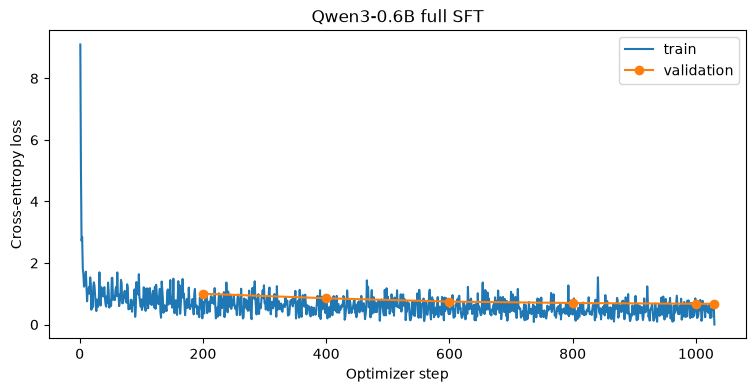

In [19]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 4))
plt.plot(
    history_df["step"],
    history_df["train_loss"],
    label="train",
)

val_points = history_df.dropna(subset=["val_loss"])

plt.plot(
    val_points["step"],
    val_points["val_loss"],
    marker="o",
    label="validation",
)

plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("Qwen3-0.6B full SFT")
plt.legend()
plt.show()

What to look for:

- train loss should decrease;
- validation loss should also decrease;
- if train keeps falling while validation rises, we're overfitting;
- if neither moves, optimization may be too weak or labels may be wrong;
- if loss explodes or becomes NaN, stop.

Do not celebrate low train loss by itself. Lab 02 already taught us how easy memorization can be.

## 7.16 Reload the best checkpoint

Do not assume the final optimizer step produced the best model.

Reload the checkpoint with the lowest validation loss.

In [20]:
del model

if device.type == "mps":
    torch.mps.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR,
    dtype=torch.float32,
).to(device)

model.eval()

print("reloaded:", CHECKPOINT_DIR)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

reloaded: ../checkpoints/qwen3-0.6b-wordle-full-sft


## 7.17 Evaluate validation loss again

In [21]:
final_val_loss = evaluate_loss(
    model,
    val_loader,
)

print("baseline validation loss:", baseline_val_loss)
print("best/final validation loss:", final_val_loss)
print(
    "relative reduction:",
    f"{1 - final_val_loss / baseline_val_loss:.1%}",
)

baseline validation loss: 8.550293193143958
best/final validation loss: 0.6751218411852332
relative reduction: 92.1%


## 7.18 Evaluate exact task accuracy

Loss is token-level.

Now score the model on exact generated outputs for each validation task.

This is closer to how the model will actually be used.

In [22]:
def normalize_response(text: str) -> str:
    return text.strip().splitlines()[0].strip().upper()

def evaluate_exact_accuracy(split, max_examples=None):
    rows = split
    if max_examples is not None:
        rows = split.select(
            range(min(max_examples, len(split)))
        )

    records = []

    for i, row in enumerate(rows):
        generated = generate_response(
            row["prompt"],
            max_new_tokens=16,
        )

        actual = normalize_response(generated)
        expected = row["response"].strip().upper()

        records.append({
            "task": row["task"],
            "expected": expected,
            "actual": actual,
            "correct": actual == expected,
        })

        if (i + 1) % 250 == 0:
            print(f"{i + 1}/{len(rows)}")

    return pd.DataFrame(records)

val_predictions = evaluate_exact_accuracy(
    dataset["validation"],
)

print("\nOVERALL")
print(f"{val_predictions['correct'].mean():.1%}")

print("\nBY TASK")
print(
    val_predictions
    .groupby("task")["correct"]
    .mean()
    .sort_values(ascending=False)
)

250/2169
500/2169
750/2169
1000/2169
1250/2169
1500/2169
1750/2169
2000/2169

OVERALL
65.1%

BY TASK
task
VALID_CANDIDATE    0.797800
CHOOSE_VALID       0.767442
NEXT_GUESS         0.018182
Name: correct, dtype: float64


This task-level breakdown matters.

A plausible result might be:

```text
VALID_CANDIDATE   high
CHOOSE_VALID      medium
NEXT_GUESS        lower
```

That would mean the model learned feedback semantics before it learned expert strategy—which would be a perfectly reasonable progression.

## 7.19 Inspect validation failures

In [23]:
failures = val_predictions.loc[
    ~val_predictions["correct"]
]

print("validation failures:", len(failures))

failures.head(30)

validation failures: 757


,task,expected,actual,correct
0,NEXT_GUESS,ADORN,SHEAR,False
1,NEXT_GUESS,FELLA,LEACH,False
3,NEXT_GUESS,SLASH,SHEAR,False
4,VALID_CANDIDATE,VALID,INVALID,False
5,NEXT_GUESS,TRAIL,SHEAR,False
6,VALID_CANDIDATE,VALID,INVALID,False
8,CHOOSE_VALID,ATTIC,ERECT,False
9,NEXT_GUESS,ADMIT,DAILY,False
13,VALID_CANDIDATE,VALID,INVALID,False
15,CHOOSE_VALID,EVADE,CLAMP,False


## 7.20 Save training metrics

Do not rely on notebook output as the experiment record.

In [24]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

history_path = RESULTS_DIR / "lab07_full_sft_training_history.csv"
summary_path = RESULTS_DIR / "lab07_full_sft_summary.json"

history_df.to_csv(history_path, index=False)

summary = {
    "model": MODEL_ID,
    "checkpoint": str(CHECKPOINT_DIR),
    "train_rows": dataset["train"].num_rows,
    "validation_rows": dataset["validation"].num_rows,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "baseline_validation_loss": baseline_val_loss,
    "best_validation_loss": best_val_loss,
    "final_validation_loss": final_val_loss,
    "validation_exact_accuracy": float(
        val_predictions["correct"].mean()
    ),
    "validation_accuracy_by_task": {
        key: float(value)
        for key, value in (
            val_predictions
            .groupby("task")["correct"]
            .mean()
            .items()
        )
    },
    "elapsed_seconds": elapsed,
}

summary_path.write_text(
    json.dumps(summary, indent=2)
)

print(history_path)
print(summary_path)

../results/lab07_full_sft_training_history.csv
../results/lab07_full_sft_summary.json


# 7.21 The real test: rerun the Wordle game benchmark

Do **not** declare victory based on curriculum accuracy.

The actual experiment is whether the fine-tuned model plays Wordle better.

Use the exact Lab 04 harness:

```text
same prompt
same strict parser
same non-thinking mode
same greedy decoding
same test answers
same game rules
```

The only thing that changes should be:

```text
base Qwen3-0.6B
        ↓
Lab 07 SFT checkpoint
```

That is a controlled before/after comparison.

## 7.22 Adapt Lab 04 model loading

In the Lab 04 notebook, replace:

```python
MODEL_ID = "Qwen/Qwen3-0.6B"
```

with:

```python
MODEL_ID = "../checkpoints/qwen3-0.6b-wordle-full-sft"
```

Then rerun the **frozen** benchmark without changing its prompts or parser.

Record:

```text
solve rate
feedback-dependent solves
valid output rate
invalid output rate
repeat guesses
history consistency rate
mean turns on wins
```

## 7.23 What counts as success?

The most important metric is not immediately solve rate.

Our measured bottleneck was:

```text
history consistency = 0%
```

So even a result like:

```text
solve rate:            5% → 20%
history consistency:   0% → 70%
```

would be major evidence that SFT taught Qwen how Wordle feedback constrains future actions.

Then we would know the remaining bottleneck is increasingly strategic.

Conversely:

```text
curriculum accuracy: 95%
history consistency:  3%
```

would tell us the synthetic tasks failed to transfer into actual game behavior.

That would be much more interesting than pretending the fine-tuning "worked" because validation loss fell.

# Lab 07 checkpoint

Send me these results in order:

1. dataset sizes and max sequence lengths;
2. baseline validation loss;
3. the three pre-training generations;
4. one-batch sanity loss + gradient norm;
5. training log at roughly steps 1, 25, 50, 100, 200;
6. validation loss at each evaluation checkpoint;
7. final/best validation loss;
8. exact validation accuracy overall and by task;
9. the rerun Lab 04 benchmark metrics.

Do not change hyperparameters mid-run unless the training is clearly broken.

One clean mediocre experiment teaches more than six half-comparable "improvements."